# 1. Projeto Final – Avaliação Causal do Prouni

Este notebook apresenta a análise causal desenvolvida para avaliar o efeito da presença de estudantes beneficiários do Programa Universidade para Todos (Prouni) sobre a conclusão em cursos presenciais de instituições privadas de ensino superior no Brasil em 2023.

A análise utiliza os microdados do Censo da Educação Superior de 2023, obtida em 17/08/2026 no site: https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-da-educacao-superior

A unidade de análise é o curso, e a pergunta causal que orienta o trabalho é:

**Qual é o efeito da presença de estudantes beneficiários do Prouni sobre a conclusão nos cursos presenciais de instituições privadas de ensino superior no Brasil em 2023?**

## 2. Carregamento da base do Censo

Nesta etapa, é realizada a leitura dos microdados do Censo da Educação Superior de 2023, que constituem a base principal desta análise.

O arquivo utilizado contém informações agregadas por curso e apresenta variáveis relacionadas às características das instituições de ensino, dos cursos, das matrículas, dos ingressantes, dos concluintes e da presença de estudantes beneficiários do Prouni.

Neste primeiro momento, a base é carregada integralmente. Os filtros necessários para definir a amostra da pesquisa serão realizados no bloco seguinte.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Caminho da pasta onde estão os dados do Censo
pasta_censo = Path(
    r"C:\Users\igo.costa\Desktop\JupyterLab\Tarefas Aulas Helio\Exercicio Final\DadosCenso\dados"
)

# Arquivo com os dados dos cursos
arquivo_cursos = pasta_censo / "MICRODADOS_CADASTRO_CURSOS_2023.csv"

# Leitura da base
censo = pd.read_csv(
    arquivo_cursos,
    sep=";",
    encoding="latin1",
    low_memory=False
)

print("Dimensão da base:", censo.shape)
print("\nPrimeiras linhas:")
display(censo.head())

Dimensão da base: (671610, 202)

Primeiras linhas:


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,IN_CAPITAL,TP_DIMENSAO,...,QT_MAT_APOIO_SOCIAL,QT_CONC_APOIO_SOCIAL,QT_ATIV_EXTRACURRICULAR,QT_ING_ATIV_EXTRACURRICULAR,QT_MAT_ATIV_EXTRACURRICULAR,QT_CONC_ATIV_EXTRACURRICULAR,QT_MOB_ACADEMICA,QT_ING_MOB_ACADEMICA,QT_MAT_MOB_ACADEMICA,QT_CONC_MOB_ACADEMICA
0,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
1,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,2,2,2,0,0,0,0,0
2,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
3,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
4,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,...,0,0,0,0,0,0,0,0,0,0


## 3. Definição da amostra

A análise é restrita aos cursos presenciais ofertados por instituições privadas de ensino superior no Brasil.

Essa delimitação é necessária porque o Prouni é direcionado principalmente ao ensino superior privado, de modo que a inclusão de cursos pertencentes à rede pública produziria um grupo de comparação pouco adequado.

Além disso, optou-se por trabalhar com os registros da dimensão que apresenta as informações consolidadas dos cursos presenciais, evitando a duplicação de cursos associada a outras dimensões da base.

Assim, a amostra analítica é formada pelos cursos que atendem simultaneamente aos seguintes critérios:

- pertencem à dimensão utilizada para os cursos presenciais;
- são ofertados por instituições da rede privada;
- possuem modalidade de ensino presencial.

In [2]:
# Definição da amostra da pesquisa
amostra = censo[
    (censo["TP_DIMENSAO"] == 1) &
    (censo["TP_REDE"] == 2) &
    (censo["TP_MODALIDADE_ENSINO"] == 1)
].copy()

print("Dimensão da base original:", censo.shape)
print("Dimensão da amostra:", amostra.shape)

print("\nDistribuição da rede:")
print(amostra["TP_REDE"].value_counts(dropna=False))

print("\nDistribuição da modalidade de ensino:")
print(amostra["TP_MODALIDADE_ENSINO"].value_counts(dropna=False))

print("\nDistribuição da dimensão:")
print(amostra["TP_DIMENSAO"].value_counts(dropna=False))

Dimensão da base original: (671610, 202)
Dimensão da amostra: (24878, 202)

Distribuição da rede:
TP_REDE
2    24878
Name: count, dtype: int64

Distribuição da modalidade de ensino:
TP_MODALIDADE_ENSINO
1    24878
Name: count, dtype: int64

Distribuição da dimensão:
TP_DIMENSAO
1    24878
Name: count, dtype: int64


## 4. Definição do tratamento

O tratamento desta análise corresponde à presença de estudantes beneficiários do Prouni no curso.

A base do Censo da Educação Superior informa separadamente a quantidade de estudantes matriculados com bolsa integral e com bolsa parcial do Prouni.

Dessa forma, foi construída uma variável binária de tratamento:

- **T = 1:** curso com pelo menos um estudante matriculado beneficiário do Prouni;
- **T = 0:** curso sem estudantes matriculados beneficiários do Prouni.

Essa definição permite comparar cursos privados presenciais com presença do programa a cursos pertencentes ao mesmo universo institucional, mas sem estudantes beneficiários.

In [3]:
# Quantidade total de matriculados beneficiários do Prouni
amostra["QT_MAT_PROUNI"] = (
    amostra["QT_MAT_PROUNII"].fillna(0)
    + amostra["QT_MAT_PROUNIP"].fillna(0)
)

# Variável binária de tratamento
amostra["T"] = (amostra["QT_MAT_PROUNI"] > 0).astype(int)

print("Distribuição do tratamento:")
print(amostra["T"].value_counts())

print("\nPercentuais:")
print(
    (amostra["T"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nQuantidade de matriculados Prouni:")
print(amostra["QT_MAT_PROUNI"].describe())

Distribuição do tratamento:
T
1    14360
0    10518
Name: count, dtype: int64

Percentuais:
T
1    57.72
0    42.28
Name: proportion, dtype: float64

Quantidade de matriculados Prouni:
count    24878.000000
mean        11.211673
std         25.570572
min          0.000000
25%          0.000000
50%          2.000000
75%         12.000000
max       1068.000000
Name: QT_MAT_PROUNI, dtype: float64


## Verificar variáveis de conclusão disponíveis no Censo

Objetivo: escolher de forma justificada qual das variaveis ou qual combinação entre elas será o nosso Y

In [4]:
# Variáveis da base relacionadas à conclusão
vars_conclusao = [
    col for col in amostra.columns
    if "CONC" in col.upper()
]

print("Variáveis relacionadas à conclusão:")
for var in vars_conclusao:
    print(var)

Variáveis relacionadas à conclusão:
QT_CONC
QT_CONC_FEM
QT_CONC_MASC
QT_CONC_DIURNO
QT_CONC_NOTURNO
QT_CONC_0_17
QT_CONC_18_24
QT_CONC_25_29
QT_CONC_30_34
QT_CONC_35_39
QT_CONC_40_49
QT_CONC_50_59
QT_CONC_60_MAIS
QT_CONC_BRANCA
QT_CONC_PRETA
QT_CONC_PARDA
QT_CONC_AMARELA
QT_CONC_INDIGENA
QT_CONC_CORND
QT_CONC_NACBRAS
QT_CONC_NACESTRANG
QT_CONC_DEFICIENTE
QT_CONC_FINANC
QT_CONC_FINANC_REEMB
QT_CONC_FIES
QT_CONC_RPFIES
QT_CONC_FINANC_REEMB_OUTROS
QT_CONC_FINANC_NREEMB
QT_CONC_PROUNII
QT_CONC_PROUNIP
QT_CONC_NRPFIES
QT_CONC_FINANC_NREEMB_OUTROS
QT_CONC_RESERVA_VAGA
QT_CONC_RVREDEPUBLICA
QT_CONC_RVETNICO
QT_CONC_RVPDEF
QT_CONC_RVSOCIAL_RF
QT_CONC_RVOUTROS
QT_CONC_PROCESCPUBLICA
QT_CONC_PROCESCPRIVADA
QT_CONC_PROCNAOINFORMADA
QT_CONC_PARFOR
QT_CONC_APOIO_SOCIAL
QT_CONC_ATIV_EXTRACURRICULAR
QT_CONC_MOB_ACADEMICA


In [5]:
# Variáveis relacionadas a vagas
vars_vagas = [
    col for col in amostra.columns
    if "VAG" in col.upper()
]

print("Variáveis relacionadas a vagas:")
for var in vars_vagas:
    print(var)

Variáveis relacionadas a vagas:
QT_ING_RESERVA_VAGA
QT_MAT_RESERVA_VAGA
QT_CONC_RESERVA_VAGA


In [6]:
print("Cursos com QT_MAT = 0:")
print((amostra["QT_MAT"] == 0).sum())

print("\nCursos com QT_MAT > 0:")
print((amostra["QT_MAT"] > 0).sum())

print("\nResumo de QT_MAT:")
display(amostra["QT_MAT"].describe())

print("\nResumo de QT_CONC:")
display(amostra["QT_CONC"].describe())

Cursos com QT_MAT = 0:
1963

Cursos com QT_MAT > 0:
22915

Resumo de QT_MAT:


count    24878.000000
mean       128.448750
std        220.244208
min          0.000000
25%         16.000000
50%         60.500000
75%        152.000000
max       5734.000000
Name: QT_MAT, dtype: float64


Resumo de QT_CONC:


count    24878.000000
mean        21.972667
std         40.021848
min          0.000000
25%          1.000000
50%         10.000000
75%         27.000000
max       1044.000000
Name: QT_CONC, dtype: float64

In [7]:
# Cursos sem matriculados, mas com concluintes
sem_mat_com_conc = amostra[
    (amostra["QT_MAT"] == 0) &
    (amostra["QT_CONC"] > 0)
]

print("Cursos com QT_MAT = 0 e QT_CONC > 0:")
print(len(sem_mat_com_conc))


# Entre cursos com matrícula, verificar concluintes maiores que matriculados
com_mat = amostra[amostra["QT_MAT"] > 0].copy()

conc_maior_mat = com_mat[
    com_mat["QT_CONC"] > com_mat["QT_MAT"]
]

print("\nCursos com QT_CONC > QT_MAT:")
print(len(conc_maior_mat))


# Indicador provisório de conclusão
com_mat["Y_CONCLUSAO"] = (
    com_mat["QT_CONC"] / com_mat["QT_MAT"]
)

print("\nResumo provisório do indicador QT_CONC / QT_MAT:")
display(com_mat["Y_CONCLUSAO"].describe())

Cursos com QT_MAT = 0 e QT_CONC > 0:
0

Cursos com QT_CONC > QT_MAT:
0

Resumo provisório do indicador QT_CONC / QT_MAT:


count    22915.000000
mean         0.247853
std          0.253776
min          0.000000
25%          0.084211
50%          0.183099
75%          0.307692
max          1.000000
Name: Y_CONCLUSAO, dtype: float64

## 5. Definição do resultado

A variável de resultado da análise representa a conclusão observada no nível do curso.

Como os cursos apresentam tamanhos diferentes, a utilização do número absoluto de concluintes poderia gerar comparações inadequadas, pois cursos maiores tendem naturalmente a apresentar maior quantidade de concluintes. Por esse motivo, foi construído um indicador proporcional.

O resultado foi definido como a razão entre o número de concluintes e o total de estudantes matriculados no curso em 2023:

**Y = QT_CONC / QT_MAT**

O indicador varia entre 0 e 1, sendo que valores maiores representam maior proporção de concluintes em relação ao total de matriculados no curso.

Foram excluídos os cursos que apresentavam zero estudantes matriculados, uma vez que não é possível calcular o indicador nesses casos.

Cabe destacar que essa medida não representa uma taxa longitudinal de conclusão de uma mesma coorte de estudantes, pois os concluintes observados em 2023 não correspondem necessariamente aos estudantes que ingressaram no mesmo ano. Assim, a variável é interpretada neste trabalho como um indicador de conclusão observado no curso em 2023.

In [8]:
# Exclusão dos cursos sem estudantes matriculados
amostra = amostra[amostra["QT_MAT"] > 0].copy()

# Construção da variável de resultado
amostra["Y_CONCLUSAO"] = (
    amostra["QT_CONC"] / amostra["QT_MAT"]
)

print("Número de cursos na amostra analítica:", len(amostra))

print("\nResumo do indicador de conclusão:")
display(amostra["Y_CONCLUSAO"].describe())

print("\nValores ausentes em Y_CONCLUSAO:")
print(amostra["Y_CONCLUSAO"].isna().sum())

Número de cursos na amostra analítica: 22915

Resumo do indicador de conclusão:


count    22915.000000
mean         0.247853
std          0.253776
min          0.000000
25%          0.084211
50%          0.183099
75%          0.307692
max          1.000000
Name: Y_CONCLUSAO, dtype: float64


Valores ausentes em Y_CONCLUSAO:
0


## 6. Definição das covariáveis

As covariáveis correspondem às características observáveis utilizadas para aumentar a comparabilidade entre os cursos com e sem presença de estudantes beneficiários do Prouni.

A seleção dessas variáveis deve considerar sua possível relação tanto com a presença do programa quanto com o resultado de conclusão. Em uma análise causal, também é importante evitar o controle indiscriminado de características que possam ser consequência do próprio tratamento.

Por esse motivo, inicialmente são priorizadas características institucionais, acadêmicas e geográficas dos cursos. Posteriormente, será avaliada a inclusão de outras variáveis disponíveis no Censo.

In [9]:
# Conferência dos grupos após a definição do resultado Y
print("Distribuição do tratamento na amostra analítica:")
print(amostra["T"].value_counts())

print("\nPercentuais:")
print(
    (amostra["T"].value_counts(normalize=True) * 100)
    .round(2)
)

# Covariáveis institucionais e acadêmicas candidatas
vars_x_iniciais = [
    "NO_REGIAO",
    "TP_ORGANIZACAO_ACADEMICA",
    "TP_CATEGORIA_ADMINISTRATIVA",
    "TP_GRAU_ACADEMICO",
    "NO_CINE_AREA_GERAL"
]

print("\nValores ausentes nas covariáveis candidatas:")
display(amostra[vars_x_iniciais].isna().sum())

Distribuição do tratamento na amostra analítica:
T
1    14360
0     8555
Name: count, dtype: int64

Percentuais:
T
1    62.67
0    37.33
Name: proportion, dtype: float64

Valores ausentes nas covariáveis candidatas:


NO_REGIAO                       0
TP_ORGANIZACAO_ACADEMICA        0
TP_CATEGORIA_ADMINISTRATIVA     0
TP_GRAU_ACADEMICO              76
NO_CINE_AREA_GERAL              0
dtype: int64

In [10]:
vars_x_iniciais = [
    "NO_REGIAO",
    "TP_ORGANIZACAO_ACADEMICA",
    "TP_CATEGORIA_ADMINISTRATIVA",
    "TP_GRAU_ACADEMICO",
    "NO_CINE_AREA_GERAL"
]

for var in vars_x_iniciais:
    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    tabela = pd.crosstab(
        amostra[var],
        amostra["T"],
        normalize="columns"
    ) * 100

    tabela.columns = ["Controle_%", "Tratado_%"]

    display(tabela.round(2))


NO_REGIAO


,Controle_%,Tratado_%
NO_REGIAO,,
Centro-Oeste,11.51,7.62
Nordeste,18.20,19.46
Norte,6.49,5.94
Sudeste,45.60,47.42
Sul,18.20,19.56



TP_ORGANIZACAO_ACADEMICA


,Controle_%,Tratado_%
TP_ORGANIZACAO_ACADEMICA,,
1,16.83,31.97
2,32.78,38.28
3,50.39,29.75



TP_CATEGORIA_ADMINISTRATIVA


,Controle_%,Tratado_%
TP_CATEGORIA_ADMINISTRATIVA,,
4,54.55,65.93
5,45.45,34.07



TP_GRAU_ACADEMICO


,Controle_%,Tratado_%
TP_GRAU_ACADEMICO,,
1.0,65.49,80.91
2.0,12.42,6.68
3.0,22.10,12.41



NO_CINE_AREA_GERAL


,Controle_%,Tratado_%
NO_CINE_AREA_GERAL,,
"Agricultura, silvicultura, pesca e veterinária",2.68,3.45
Artes e humanidades,4.23,3.57
"Ciências naturais, matemática e estatística",0.81,0.93
"Ciências sociais, comunicação e informação",5.73,7.66
Computação e Tecnologias da Informação e Comunicação (TIC),6.69,6.78
Educação,12.40,6.66
"Engenharia, produção e construção",13.85,16.73
"Negócios, administração e direito",30.12,24.76
Programas básicos,0.36,0.29


In [11]:
# Tratamento dos valores ausentes em grau acadêmico
amostra["TP_GRAU_ACADEMICO"] = (
    amostra["TP_GRAU_ACADEMICO"]
    .fillna("Não informado")
    .astype(str)
)

# Lista final de covariáveis
covariaveis = [
    "NO_REGIAO",
    "TP_ORGANIZACAO_ACADEMICA",
    "TP_CATEGORIA_ADMINISTRATIVA",
    "TP_GRAU_ACADEMICO",
    "NO_CINE_AREA_GERAL"
]

print("Covariáveis selecionadas:")
for x in covariaveis:
    print("-", x)

print("\nValores ausentes após o tratamento:")
display(amostra[covariaveis].isna().sum())

Covariáveis selecionadas:
- NO_REGIAO
- TP_ORGANIZACAO_ACADEMICA
- TP_CATEGORIA_ADMINISTRATIVA
- TP_GRAU_ACADEMICO
- NO_CINE_AREA_GERAL

Valores ausentes após o tratamento:


NO_REGIAO                      0
TP_ORGANIZACAO_ACADEMICA       0
TP_CATEGORIA_ADMINISTRATIVA    0
TP_GRAU_ACADEMICO              0
NO_CINE_AREA_GERAL             0
dtype: int64

## 7. Análise descritiva dos grupos

Antes da aplicação dos métodos causais, é importante comparar os cursos tratados e controles em sua forma original.

Nesta etapa, são apresentadas estatísticas descritivas do tratamento, do indicador de conclusão e das principais características observáveis dos cursos.

Essa comparação representa o cenário anterior ao ajuste. Eventuais diferenças observadas entre os grupos ainda não devem ser interpretadas como efeito causal do Prouni, pois tratados e controles podem diferir em características que também influenciam a conclusão.

In [12]:
# Tamanho dos grupos
resumo_grupos = amostra.groupby("T")["Y_CONCLUSAO"].agg(
    N="count",
    Media="mean",
    Mediana="median",
    Desvio_Padrao="std",
    Minimo="min",
    Maximo="max"
)

resumo_grupos.index = ["Controle", "Tratado"]

display(resumo_grupos.round(4))

# Diferença bruta entre as médias
media_controle = amostra.loc[amostra["T"] == 0, "Y_CONCLUSAO"].mean()
media_tratado = amostra.loc[amostra["T"] == 1, "Y_CONCLUSAO"].mean()

diferenca_bruta = media_tratado - media_controle

print("\nDiferença bruta das médias:")
print(round(diferenca_bruta, 4))

,N,Media,Mediana,Desvio_Padrao,Minimo,Maximo
Controle,8555,0.2856,0.1748,0.3249,0.0,1.0
Tratado,14360,0.2254,0.1857,0.1963,0.0,1.0



Diferença bruta das médias:
-0.0602


In [13]:
for var in covariaveis:
    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    tabela = pd.crosstab(
        amostra[var],
        amostra["T"],
        normalize="columns"
    ) * 100

    tabela.columns = ["Controle_%", "Tratado_%"]

    display(tabela.round(2))


NO_REGIAO


,Controle_%,Tratado_%
NO_REGIAO,,
Centro-Oeste,11.51,7.62
Nordeste,18.20,19.46
Norte,6.49,5.94
Sudeste,45.60,47.42
Sul,18.20,19.56



TP_ORGANIZACAO_ACADEMICA


,Controle_%,Tratado_%
TP_ORGANIZACAO_ACADEMICA,,
1,16.83,31.97
2,32.78,38.28
3,50.39,29.75



TP_CATEGORIA_ADMINISTRATIVA


,Controle_%,Tratado_%
TP_CATEGORIA_ADMINISTRATIVA,,
4,54.55,65.93
5,45.45,34.07



TP_GRAU_ACADEMICO


,Controle_%,Tratado_%
TP_GRAU_ACADEMICO,,
1.0,65.23,80.68
2.0,12.37,6.66
3.0,22.01,12.37
Não informado,0.40,0.29



NO_CINE_AREA_GERAL


,Controle_%,Tratado_%
NO_CINE_AREA_GERAL,,
"Agricultura, silvicultura, pesca e veterinária",2.68,3.45
Artes e humanidades,4.23,3.57
"Ciências naturais, matemática e estatística",0.81,0.93
"Ciências sociais, comunicação e informação",5.73,7.66
Computação e Tecnologias da Informação e Comunicação (TIC),6.69,6.78
Educação,12.40,6.66
"Engenharia, produção e construção",13.85,16.73
"Negócios, administração e direito",30.12,24.76
Programas básicos,0.36,0.29


## 8. Método causal 1: Propensity Score Matching (PSM)

O primeiro método causal utilizado é o Propensity Score Matching (PSM).

Como os cursos com e sem presença de estudantes beneficiários do Prouni apresentam diferenças em características observáveis, a comparação direta entre os grupos pode produzir estimativas enviesadas.

O PSM busca aumentar a comparabilidade entre os grupos por meio do propensity score, definido como a probabilidade de um curso apresentar o tratamento, dadas suas características observáveis.

Neste trabalho, o tratamento corresponde à presença de estudantes beneficiários do Prouni no curso, enquanto as covariáveis utilizadas são características institucionais, acadêmicas e geográficas previamente selecionadas.

A estratégia consiste em:

1. estimar o propensity score de cada curso;
2. verificar a existência de suporte comum entre tratados e controles;
3. parear cursos tratados com cursos controles que apresentem propensity scores semelhantes;
4. avaliar o balanceamento das covariáveis após o pareamento;
5. estimar o efeito médio do tratamento sobre os tratados (ATT).

In [14]:
# Seleção das covariáveis
X = amostra[covariaveis].copy()

# Transformação das variáveis categóricas em dummies
X_dummies = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

# Variável de tratamento
T = amostra["T"].copy()

print("Dimensão da matriz original de covariáveis:", X.shape)
print("Dimensão após criação das dummies:", X_dummies.shape)

print("\nPrimeiras variáveis após transformação:")
print(X_dummies.columns.tolist())

print("\nValores ausentes em X_dummies:")
print(X_dummies.isna().sum().sum())

Dimensão da matriz original de covariáveis: (22915, 5)
Dimensão após criação das dummies: (22915, 19)

Primeiras variáveis após transformação:
['TP_ORGANIZACAO_ACADEMICA', 'TP_CATEGORIA_ADMINISTRATIVA', 'NO_REGIAO_Nordeste', 'NO_REGIAO_Norte', 'NO_REGIAO_Sudeste', 'NO_REGIAO_Sul', 'TP_GRAU_ACADEMICO_2.0', 'TP_GRAU_ACADEMICO_3.0', 'TP_GRAU_ACADEMICO_Não informado', 'NO_CINE_AREA_GERAL_Artes e humanidades', 'NO_CINE_AREA_GERAL_Ciências naturais, matemática e estatística', 'NO_CINE_AREA_GERAL_Ciências sociais, comunicação e informação', 'NO_CINE_AREA_GERAL_Computação e Tecnologias da Informação e Comunicação (TIC)', 'NO_CINE_AREA_GERAL_Educação', 'NO_CINE_AREA_GERAL_Engenharia, produção e construção', 'NO_CINE_AREA_GERAL_Negócios, administração e direito', 'NO_CINE_AREA_GERAL_Programas básicos', 'NO_CINE_AREA_GERAL_Saúde e bem-estar', 'NO_CINE_AREA_GERAL_Serviços']

Valores ausentes em X_dummies:
0


In [15]:
# Seleção das covariáveis
X = amostra[covariaveis].copy()

# Todas as covariáveis selecionadas são tratadas como categóricas
for col in X.columns:
    X[col] = X[col].astype(str)

# Transformação das categorias em variáveis dummies
X_dummies = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

# Variável de tratamento
T = amostra["T"].copy()

print("Dimensão da matriz original de covariáveis:", X.shape)
print("Dimensão após criação das dummies:", X_dummies.shape)

print("\nVariáveis após transformação:")
for col in X_dummies.columns:
    print(col)

print("\nValores ausentes em X_dummies:")
print(X_dummies.isna().sum().sum())

Dimensão da matriz original de covariáveis: (22915, 5)
Dimensão após criação das dummies: (22915, 20)

Variáveis após transformação:
NO_REGIAO_Nordeste
NO_REGIAO_Norte
NO_REGIAO_Sudeste
NO_REGIAO_Sul
TP_ORGANIZACAO_ACADEMICA_2
TP_ORGANIZACAO_ACADEMICA_3
TP_CATEGORIA_ADMINISTRATIVA_5
TP_GRAU_ACADEMICO_2.0
TP_GRAU_ACADEMICO_3.0
TP_GRAU_ACADEMICO_Não informado
NO_CINE_AREA_GERAL_Artes e humanidades
NO_CINE_AREA_GERAL_Ciências naturais, matemática e estatística
NO_CINE_AREA_GERAL_Ciências sociais, comunicação e informação
NO_CINE_AREA_GERAL_Computação e Tecnologias da Informação e Comunicação (TIC)
NO_CINE_AREA_GERAL_Educação
NO_CINE_AREA_GERAL_Engenharia, produção e construção
NO_CINE_AREA_GERAL_Negócios, administração e direito
NO_CINE_AREA_GERAL_Programas básicos
NO_CINE_AREA_GERAL_Saúde e bem-estar
NO_CINE_AREA_GERAL_Serviços

Valores ausentes em X_dummies:
0


### 8.2 Estimação do propensity score

O propensity score representa a probabilidade estimada de uma unidade receber o tratamento condicionada às covariáveis observadas.

Neste trabalho, ele corresponde à probabilidade de um curso apresentar estudantes beneficiários do Prouni, considerando características institucionais, acadêmicas e geográficas.

A estimação é realizada por meio de regressão logística, utilizando como variável dependente o tratamento `T` e como preditores as covariáveis previamente transformadas em variáveis indicadoras.

In [16]:
from sklearn.linear_model import LogisticRegression

# Modelo de regressão logística
modelo_ps = LogisticRegression(
    max_iter=2000
)

# Ajuste do modelo
modelo_ps.fit(X_dummies, T)

# Probabilidade estimada de receber o tratamento
amostra["PSCORE"] = modelo_ps.predict_proba(X_dummies)[:, 1]

print("Resumo do propensity score:")
display(amostra["PSCORE"].describe())

print("\nPropensity score por grupo:")
display(
    amostra.groupby("T")["PSCORE"].describe().round(4)
)

Resumo do propensity score:


count    22915.000000
mean         0.626757
std          0.160319
min          0.126393
25%          0.544743
50%          0.627877
75%          0.761666
max          0.900244
Name: PSCORE, dtype: float64


Propensity score por grupo:


,count,mean,std,min,25%,50%,75%,max
T,,,,,,,,
0,8555.0,0.5575,0.1665,0.1264,0.4216,0.5861,0.6473,0.9002
1,14360.0,0.6680,0.1412,0.1833,0.5863,0.6599,0.7757,0.8928


### 8.3 Verificação do suporte comum

Após a estimação do propensity score, é necessário verificar se existem cursos tratados e controles com probabilidades estimadas semelhantes de receber o tratamento.

Essa condição é conhecida como suporte comum. A existência de sobreposição entre as distribuições do propensity score permite realizar comparações entre unidades tratadas e controles que apresentam características observáveis semelhantes.

Cursos localizados fora da região de sobreposição não possuem unidades adequadamente comparáveis no outro grupo e, por esse motivo, podem ser excluídos da etapa de pareamento.

In [17]:
# Limites do suporte comum
min_tratado = amostra.loc[amostra["T"] == 1, "PSCORE"].min()
max_tratado = amostra.loc[amostra["T"] == 1, "PSCORE"].max()

min_controle = amostra.loc[amostra["T"] == 0, "PSCORE"].min()
max_controle = amostra.loc[amostra["T"] == 0, "PSCORE"].max()

limite_inferior = max(min_tratado, min_controle)
limite_superior = min(max_tratado, max_controle)

print("Limite inferior do suporte comum:", round(limite_inferior, 4))
print("Limite superior do suporte comum:", round(limite_superior, 4))

# Identificação das observações dentro do suporte comum
amostra["SUPORTE_COMUM"] = (
    (amostra["PSCORE"] >= limite_inferior) &
    (amostra["PSCORE"] <= limite_superior)
)

print("\nCursos dentro e fora do suporte comum:")
print(amostra["SUPORTE_COMUM"].value_counts())

print("\nPor grupo:")
display(
    pd.crosstab(
        amostra["T"],
        amostra["SUPORTE_COMUM"]
    )
)

Limite inferior do suporte comum: 0.1833
Limite superior do suporte comum: 0.8928

Cursos dentro e fora do suporte comum:
SUPORTE_COMUM
True     22879
False       36
Name: count, dtype: int64

Por grupo:


SUPORTE_COMUM,False,True
T,,
0,36,8519
1,0,14360


### 8.4 Distribuição do propensity score

A análise do suporte comum mostrou ampla sobreposição entre os grupos tratado e controle. Dos 22.915 cursos da amostra analítica, 22.879 encontram-se na região de suporte comum, com exclusão de apenas 36 cursos do grupo controle.

Nenhum curso tratado foi excluído nessa etapa, indicando que todos os cursos com presença de estudantes beneficiários do Prouni possuem propensity scores dentro da faixa observada entre os controles.

A seguir, são visualizadas as distribuições do propensity score nos dois grupos antes do pareamento. Essa representação permite observar graficamente o grau de sobreposição entre tratados e controles.

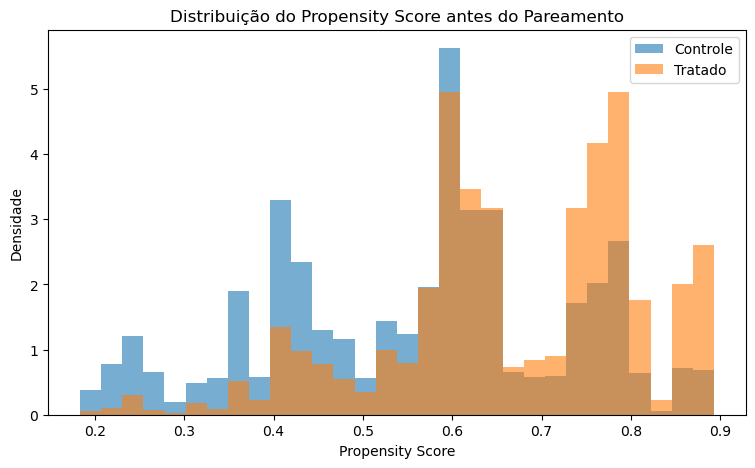

In [18]:
import matplotlib.pyplot as plt

dados_suporte = amostra[amostra["SUPORTE_COMUM"]].copy()

plt.figure(figsize=(9, 5))

plt.hist(
    dados_suporte.loc[dados_suporte["T"] == 0, "PSCORE"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Controle"
)

plt.hist(
    dados_suporte.loc[dados_suporte["T"] == 1, "PSCORE"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Tratado"
)

plt.xlabel("Propensity Score")
plt.ylabel("Densidade")
plt.title("Distribuição do Propensity Score antes do Pareamento")
plt.legend()

plt.show()

### 8.5 Pareamento pelo vizinho mais próximo

Após a verificação do suporte comum, os cursos tratados são pareados a cursos controles com propensity scores semelhantes.

Foi utilizado o pareamento 1:1 pelo método do vizinho mais próximo. Para cada curso com presença de estudantes beneficiários do Prouni, é selecionado o curso sem presença de beneficiários que apresenta o propensity score mais próximo.

Como o número de cursos tratados é superior ao número de cursos controles disponíveis, o pareamento é realizado com reposição. Dessa forma, um mesmo curso do grupo controle pode ser utilizado como comparação para mais de um curso tratado.

Essa estratégia busca construir, para os cursos efetivamente tratados, um grupo contrafactual composto por cursos observacionalmente semelhantes que não apresentam estudantes beneficiários do Prouni.

In [19]:
from sklearn.neighbors import NearestNeighbors

# Separação dos grupos dentro do suporte comum
tratados = dados_suporte[dados_suporte["T"] == 1].copy()
controles = dados_suporte[dados_suporte["T"] == 0].copy()

# Modelo de vizinho mais próximo usando o propensity score
nn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

nn.fit(controles[["PSCORE"]])

# Para cada tratado, localizar o controle mais próximo
distancias, posicoes = nn.kneighbors(
    tratados[["PSCORE"]]
)

# Índices dos controles selecionados
indices_controles = controles.iloc[posicoes.flatten()].index

# Tabela com os pares
pares = pd.DataFrame({
    "indice_tratado": tratados.index,
    "indice_controle": indices_controles,
    "pscore_tratado": tratados["PSCORE"].values,
    "pscore_controle": controles.loc[
        indices_controles, "PSCORE"
    ].values,
    "distancia_pscore": distancias.flatten()
})

print("Número de tratados pareados:", len(pares))

print(
    "Número de controles distintos utilizados:",
    pares["indice_controle"].nunique()
)

print("\nResumo da distância entre os propensity scores:")
display(pares["distancia_pscore"].describe())

print("\nPrimeiros pares:")
display(pares.head())

Número de tratados pareados: 14360
Número de controles distintos utilizados: 374

Resumo da distância entre os propensity scores:


count    14360.000000
mean         0.000010
std          0.000175
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.007951
Name: distancia_pscore, dtype: float64


Primeiros pares:


,indice_tratado,indice_controle,pscore_tratado,pscore_controle,distancia_pscore
0,11185,11221,0.801803,0.801803,0.0
1,11186,11207,0.664970,0.664970,0.0
2,11187,11202,0.806571,0.806571,0.0
3,11188,56614,0.828422,0.828422,0.0
4,11189,41816,0.837212,0.837212,0.0


### 8.6 Diagnóstico do pareamento

O pareamento inicial encontrou um controle para todos os cursos tratados e apresentou distâncias muito pequenas entre os propensity scores dos pares.

Entretanto, observou-se que apenas 374 cursos controles distintos foram utilizados para representar os 14.360 cursos tratados. Como o pareamento foi realizado com reposição, um mesmo controle pode ser utilizado mais de uma vez.

Diante da elevada reutilização observada, torna-se necessário examinar a frequência com que cada controle foi selecionado e verificar a ocorrência de valores repetidos do propensity score antes de definir o pareamento final.

In [20]:
# Quantas vezes cada controle foi utilizado
uso_controles = (
    pares["indice_controle"]
    .value_counts()
)

print("Resumo do número de vezes que cada controle foi utilizado:")
display(uso_controles.describe())

print("\n10 controles mais reutilizados:")
display(uso_controles.head(10))


# Quantidade de valores distintos de propensity score
print("\nValores distintos de propensity score:")

print(
    "Tratados:",
    tratados["PSCORE"].nunique()
)

print(
    "Controles:",
    controles["PSCORE"].nunique()
)

print(
    "Amostra total no suporte:",
    dados_suporte["PSCORE"].nunique()
)


# Quantidade de pares com distância exatamente zero
pares_distancia_zero = (
    pares["distancia_pscore"] == 0
).sum()

print(
    "\nPares com distância exatamente zero:",
    pares_distancia_zero
)

print(
    "Percentual:",
    round(
        pares_distancia_zero / len(pares) * 100,
        2
    ),
    "%"
)

Resumo do número de vezes que cada controle foi utilizado:


count    374.000000
mean      38.395722
std       64.834610
min        1.000000
25%        4.250000
50%       13.000000
75%       37.750000
max      397.000000
Name: count, dtype: float64


10 controles mais reutilizados:


indice_controle
84681     397
351164    394
67852     360
273926    327
274012    316
255271    296
386021    285
265066    269
266435    252
258355    248
Name: count, dtype: int64


Valores distintos de propensity score:
Tratados: 409
Controles: 433
Amostra total no suporte: 482

Pares com distância exatamente zero: 14241
Percentual: 99.17 %


### 8.7 Tratamento dos empates no pareamento

O diagnóstico do pareamento inicial mostrou que 99,17% dos cursos tratados possuíam controles com propensity score exatamente igual. Entretanto, o algoritmo de vizinho mais próximo utilizou apenas 374 controles distintos, com alguns controles sendo selecionados centenas de vezes.

Esse resultado decorre da existência de muitos empates no propensity score. Como as covariáveis utilizadas são categóricas, diferentes cursos podem apresentar exatamente a mesma combinação de características e, consequentemente, o mesmo propensity score.

Nessas situações, não há fundamento para selecionar sistematicamente um único controle entre vários controles igualmente próximos. Por esse motivo, o pareamento foi ajustado para realizar seleção aleatória entre os controles empatados, mantendo uma semente fixa para garantir a reprodutibilidade da análise.

O pareamento continua sendo realizado na proporção 1:1, com reposição, tendo como objetivo a estimação do efeito médio do tratamento sobre os tratados (ATT).

In [22]:
# Gerador aleatório com semente fixa para reprodutibilidade
rng = np.random.default_rng(42)

# Arrays para armazenar os pares
pares_final_lista = []

# Propensity scores dos controles
ps_controles = controles["PSCORE"].to_numpy()

for indice_tratado, linha_tratado in tratados.iterrows():
    
    ps_tratado = linha_tratado["PSCORE"]
    
    # Distância absoluta entre o tratado e todos os controles
    distancias = np.abs(ps_controles - ps_tratado)
    
    # Menor distância encontrada
    menor_distancia = distancias.min()
    
    # Todos os controles empatados na menor distância
    posicoes_empatadas = np.where(
        np.isclose(distancias, menor_distancia, atol=1e-12)
    )[0]
    
    # Sorteio de um dos controles igualmente próximos
    posicao_escolhida = rng.choice(posicoes_empatadas)
    
    indice_controle = controles.index[posicao_escolhida]
    ps_controle = controles.iloc[posicao_escolhida]["PSCORE"]
    
    pares_final_lista.append({
        "indice_tratado": indice_tratado,
        "indice_controle": indice_controle,
        "pscore_tratado": ps_tratado,
        "pscore_controle": ps_controle,
        "distancia_pscore": menor_distancia
    })

pares_final = pd.DataFrame(pares_final_lista)

print("Número de tratados pareados:", len(pares_final))

print(
    "Número de controles distintos utilizados:",
    pares_final["indice_controle"].nunique()
)

print("\nResumo da distância entre os propensity scores:")
display(pares_final["distancia_pscore"].describe())

print("\nResumo da reutilização dos controles:")
display(
    pares_final["indice_controle"]
    .value_counts()
    .describe()
)

print("\n10 controles mais reutilizados:")
display(
    pares_final["indice_controle"]
    .value_counts()
    .head(10)
)

Número de tratados pareados: 14360
Número de controles distintos utilizados: 5640

Resumo da distância entre os propensity scores:


count    14360.000000
mean         0.000010
std          0.000175
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.007951
Name: distancia_pscore, dtype: float64


Resumo da reutilização dos controles:


count    5640.000000
mean        2.546099
std         2.268938
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        29.000000
Name: count, dtype: float64


10 controles mais reutilizados:


indice_controle
506709    29
11277     25
11278     24
505972    22
370997    22
506788    19
506313    19
506048    19
419684    19
506874    18
Name: count, dtype: int64

### 8.8 Avaliação do balanceamento após o pareamento

A proximidade entre os propensity scores dos pares não é suficiente, isoladamente, para demonstrar que o pareamento produziu grupos comparáveis.

Por esse motivo, o balanceamento das covariáveis é avaliado antes e depois do pareamento por meio da diferença média padronizada (Standardized Mean Difference – SMD).

Valores de SMD próximos de zero indicam maior semelhança entre tratados e controles. Como referência prática, valores absolutos inferiores a 0,10 são geralmente considerados indicativos de bom balanceamento.

A comparação entre o SMD antes e depois do pareamento permite verificar se o PSM reduziu efetivamente as diferenças observáveis entre os grupos.

In [23]:
# Amostras correspondentes aos pares finais
tratados_pareados = amostra.loc[
    pares_final["indice_tratado"]
].copy()

controles_pareados = amostra.loc[
    pares_final["indice_controle"]
].copy()

# Garantir alinhamento linha a linha
tratados_pareados = tratados_pareados.reset_index(drop=True)
controles_pareados = controles_pareados.reset_index(drop=True)

print("Tratados na amostra pareada:", len(tratados_pareados))
print("Controles na amostra pareada:", len(controles_pareados))


# Matrizes de covariáveis para cálculo do balanceamento
X_antes = X_dummies.copy()

X_tratados_depois = X_dummies.loc[
    pares_final["indice_tratado"]
].reset_index(drop=True)

X_controles_depois = X_dummies.loc[
    pares_final["indice_controle"]
].reset_index(drop=True)


# Função para calcular SMD
def calcular_smd(media_t, media_c, var_t, var_c):
    denominador = np.sqrt((var_t + var_c) / 2)

    if denominador == 0:
        return 0

    return (media_t - media_c) / denominador


resultados_smd = []

for var in X_dummies.columns:

    # Antes do pareamento
    x_t_antes = X_antes.loc[T == 1, var]
    x_c_antes = X_antes.loc[T == 0, var]

    smd_antes = calcular_smd(
        x_t_antes.mean(),
        x_c_antes.mean(),
        x_t_antes.var(),
        x_c_antes.var()
    )

    # Depois do pareamento
    x_t_depois = X_tratados_depois[var]
    x_c_depois = X_controles_depois[var]

    smd_depois = calcular_smd(
        x_t_depois.mean(),
        x_c_depois.mean(),
        x_t_depois.var(),
        x_c_depois.var()
    )

    resultados_smd.append({
        "Variavel": var,
        "SMD_Antes": smd_antes,
        "SMD_Depois": smd_depois,
        "Abs_SMD_Antes": abs(smd_antes),
        "Abs_SMD_Depois": abs(smd_depois)
    })


balanceamento_psm = pd.DataFrame(resultados_smd)

balanceamento_psm = balanceamento_psm.sort_values(
    "Abs_SMD_Depois",
    ascending=False
)

display(balanceamento_psm.round(4))

print(
    "\nMaior |SMD| antes do pareamento:",
    round(balanceamento_psm["Abs_SMD_Antes"].max(), 4)
)

print(
    "Maior |SMD| depois do pareamento:",
    round(balanceamento_psm["Abs_SMD_Depois"].max(), 4)
)

print(
    "\nNúmero de covariáveis com |SMD| >= 0,10 depois:",
    (balanceamento_psm["Abs_SMD_Depois"] >= 0.10).sum()
)

Tratados na amostra pareada: 14360
Controles na amostra pareada: 14360


,Variavel,SMD_Antes,SMD_Depois,Abs_SMD_Antes,Abs_SMD_Depois
11,"NO_CINE_AREA_GERAL_Ciências naturais, matemáti...",0.0129,0.0128,0.0129,0.0128
19,NO_CINE_AREA_GERAL_Serviços,-0.0497,0.0079,0.0497,0.0079
18,NO_CINE_AREA_GERAL_Saúde e bem-estar,0.1622,-0.0053,0.1622,0.0053
16,"NO_CINE_AREA_GERAL_Negócios, administração e d...",-0.1203,-0.0048,0.1203,0.0048
17,NO_CINE_AREA_GERAL_Programas básicos,-0.0122,0.0039,0.0122,0.0039
9,TP_GRAU_ACADEMICO_Não informado,-0.0179,0.0039,0.0179,0.0039
12,"NO_CINE_AREA_GERAL_Ciências sociais, comunicaç...",0.0774,0.0031,0.0774,0.0031
2,NO_REGIAO_Sudeste,0.0364,-0.0031,0.0364,0.0031
8,TP_GRAU_ACADEMICO_3.0,-0.2575,0.0025,0.2575,0.0025
1,NO_REGIAO_Norte,-0.0227,0.0024,0.0227,0.0024



Maior |SMD| antes do pareamento: 0.4309
Maior |SMD| depois do pareamento: 0.0128

Número de covariáveis com |SMD| >= 0,10 depois: 0


### 8.9 Estimação do efeito médio do tratamento sobre os tratados

Após o pareamento, foi verificado o balanceamento das covariáveis entre os grupos tratado e controle.

Antes do ajuste, algumas covariáveis apresentavam diferenças médias padronizadas relevantes, com valor absoluto máximo de 0,431. Após o pareamento, o maior valor absoluto do SMD foi reduzido para aproximadamente 0,013, e nenhuma das covariáveis apresentou |SMD| igual ou superior a 0,10.

Esses resultados indicam que o Propensity Score Matching aumentou substancialmente a comparabilidade entre os grupos em relação às características observadas utilizadas no modelo.

Com os grupos balanceados, o efeito médio do tratamento sobre os tratados (ATT) é estimado pela diferença entre o indicador de conclusão de cada curso tratado e o indicador observado no respectivo curso controle pareado.

In [24]:
# Resultado dos tratados e respectivos controles pareados
y_tratados = tratados_pareados["Y_CONCLUSAO"].to_numpy()
y_controles = controles_pareados["Y_CONCLUSAO"].to_numpy()

# Diferença individual de cada par
efeito_pares = y_tratados - y_controles

# ATT
att_psm = efeito_pares.mean()

print("Média de Y nos tratados pareados:")
print(round(y_tratados.mean(), 4))

print("\nMédia de Y nos controles pareados:")
print(round(y_controles.mean(), 4))

print("\nATT estimado pelo PSM:")
print(round(att_psm, 4))

print("\nATT em pontos percentuais:")
print(round(att_psm * 100, 2), "p.p.")

Média de Y nos tratados pareados:
0.2254

Média de Y nos controles pareados:
0.2709

ATT estimado pelo PSM:
-0.0456

ATT em pontos percentuais:
-4.56 p.p.


## 9. Método causal 2: Inverse Probability Weighting (IPW)

O segundo método causal utilizado é a ponderação pelo inverso da probabilidade de tratamento, conhecida como Inverse Probability Weighting (IPW).

Diferentemente do pareamento, que seleciona cursos controles semelhantes aos tratados, o IPW atribui pesos às observações de modo a construir uma população ponderada em que as características observáveis dos grupos se tornem mais comparáveis.

Como o objetivo deste trabalho é estimar o efeito médio do tratamento sobre os tratados (ATT), os cursos tratados recebem peso igual a 1, enquanto os cursos controles recebem pesos calculados a partir do propensity score.

Para os controles, o peso é definido como:

**peso = PSCORE / (1 - PSCORE)**

Dessa forma, cursos controles com características semelhantes às dos cursos tratados recebem maior importância na população ponderada.

In [25]:
# Base dentro do suporte comum
ipw = dados_suporte.copy()

# Pesos para estimar o ATT
ipw["PESO_ATT"] = np.where(
    ipw["T"] == 1,
    1,
    ipw["PSCORE"] / (1 - ipw["PSCORE"])
)

print("Resumo dos pesos ATT:")
display(ipw["PESO_ATT"].describe())

print("\nResumo dos pesos por grupo:")
display(
    ipw.groupby("T")["PESO_ATT"]
    .describe()
    .round(4)
)

print("\nMaior peso observado:")
print(round(ipw["PESO_ATT"].max(), 4))

Resumo dos pesos ATT:


count    22879.000000
mean         1.261152
std          0.881866
min          0.224491
25%          1.000000
50%          1.000000
75%          1.000000
max          8.325656
Name: PESO_ATT, dtype: float64


Resumo dos pesos por grupo:


,count,mean,std,min,25%,50%,75%,max
T,,,,,,,,
0,8519.0,1.7014,1.3342,0.2245,0.7289,1.417,1.8472,8.3257
1,14360.0,1.0000,0.0000,1.0000,1.0000,1.000,1.0000,1.0000



Maior peso observado:
8.3257


### 9.2 Avaliação do balanceamento após a ponderação

Após a construção dos pesos para o ATT, é necessário verificar se a ponderação tornou os cursos tratados e controles mais semelhantes em relação às covariáveis observadas.

Assim como no PSM, o balanceamento é avaliado por meio da diferença média padronizada (SMD). Antes do ajuste, o SMD representa as diferenças existentes entre os grupos originais. Após o IPW, médias e variâncias dos controles são calculadas considerando os pesos atribuídos a cada observação.

Valores absolutos de SMD inferiores a 0,10 são utilizados como referência prática de bom balanceamento.

In [26]:
# Matriz de covariáveis apenas para os cursos no suporte comum
X_ipw = X_dummies.loc[ipw.index].copy()

T_ipw = ipw["T"]
W_ipw = ipw["PESO_ATT"]


# Funções para média e variância ponderadas
def media_ponderada(x, w):
    return np.average(x, weights=w)


def variancia_ponderada(x, w):
    media = media_ponderada(x, w)
    return np.average((x - media) ** 2, weights=w)


resultados_smd_ipw = []

for var in X_ipw.columns:

    # ---------------------------
    # Antes do IPW
    # ---------------------------
    x_t_antes = X_ipw.loc[T_ipw == 1, var]
    x_c_antes = X_ipw.loc[T_ipw == 0, var]

    smd_antes = calcular_smd(
        x_t_antes.mean(),
        x_c_antes.mean(),
        x_t_antes.var(),
        x_c_antes.var()
    )

    # ---------------------------
    # Depois do IPW
    # ---------------------------
    x_t = X_ipw.loc[T_ipw == 1, var]
    x_c = X_ipw.loc[T_ipw == 0, var]

    w_t = W_ipw.loc[T_ipw == 1]
    w_c = W_ipw.loc[T_ipw == 0]

    media_t = media_ponderada(x_t, w_t)
    media_c = media_ponderada(x_c, w_c)

    var_t = variancia_ponderada(x_t, w_t)
    var_c = variancia_ponderada(x_c, w_c)

    smd_depois = calcular_smd(
        media_t,
        media_c,
        var_t,
        var_c
    )

    resultados_smd_ipw.append({
        "Variavel": var,
        "SMD_Antes": smd_antes,
        "SMD_Depois": smd_depois,
        "Abs_SMD_Antes": abs(smd_antes),
        "Abs_SMD_Depois": abs(smd_depois)
    })


balanceamento_ipw = pd.DataFrame(resultados_smd_ipw)

balanceamento_ipw = balanceamento_ipw.sort_values(
    "Abs_SMD_Depois",
    ascending=False
)

display(balanceamento_ipw.round(4))

print(
    "\nMaior |SMD| antes do IPW:",
    round(balanceamento_ipw["Abs_SMD_Antes"].max(), 4)
)

print(
    "Maior |SMD| depois do IPW:",
    round(balanceamento_ipw["Abs_SMD_Depois"].max(), 4)
)

print(
    "\nNúmero de covariáveis com |SMD| >= 0,10 depois:",
    (balanceamento_ipw["Abs_SMD_Depois"] >= 0.10).sum()
)

,Variavel,SMD_Antes,SMD_Depois,Abs_SMD_Antes,Abs_SMD_Depois
3,NO_REGIAO_Sul,0.0328,-0.0494,0.0328,0.0494
1,NO_REGIAO_Norte,-0.0238,-0.0308,0.0238,0.0308
16,"NO_CINE_AREA_GERAL_Negócios, administração e d...",-0.1177,0.0304,0.1177,0.0304
0,NO_REGIAO_Nordeste,0.0306,0.0254,0.0306,0.0254
2,NO_REGIAO_Sudeste,0.0326,0.0238,0.0326,0.0238
4,TP_ORGANIZACAO_ACADEMICA_2,0.1122,0.0137,0.1122,0.0137
5,TP_ORGANIZACAO_ACADEMICA_3,-0.4267,0.0137,0.4267,0.0137
18,NO_CINE_AREA_GERAL_Saúde e bem-estar,0.1607,-0.0136,0.1607,0.0136
13,NO_CINE_AREA_GERAL_Computação e Tecnologias da...,0.0024,-0.0123,0.0024,0.0123
15,"NO_CINE_AREA_GERAL_Engenharia, produção e cons...",0.0812,-0.0090,0.0812,0.0090



Maior |SMD| antes do IPW: 0.4267
Maior |SMD| depois do IPW: 0.0494

Número de covariáveis com |SMD| >= 0,10 depois: 0


### 9.3 Estimação do efeito médio do tratamento sobre os tratados

A avaliação do balanceamento mostrou que a ponderação por IPW reduziu substancialmente as diferenças observáveis entre os grupos.

Antes do ajuste, o maior valor absoluto do SMD era de aproximadamente 0,427. Após a ponderação, o maior |SMD| foi reduzido para aproximadamente 0,049, e nenhuma covariável apresentou |SMD| igual ou superior a 0,10.

Com os grupos ponderados adequadamente balanceados, o efeito médio do tratamento sobre os tratados (ATT) é estimado comparando o indicador médio de conclusão dos cursos tratados com a média ponderada dos cursos controles.

In [27]:
# Separação dos grupos
ipw_tratados = ipw[ipw["T"] == 1].copy()
ipw_controles = ipw[ipw["T"] == 0].copy()

# Média do resultado entre os tratados
media_y_tratados_ipw = np.average(
    ipw_tratados["Y_CONCLUSAO"],
    weights=ipw_tratados["PESO_ATT"]
)

# Média ponderada do resultado entre os controles
media_y_controles_ipw = np.average(
    ipw_controles["Y_CONCLUSAO"],
    weights=ipw_controles["PESO_ATT"]
)

# ATT
att_ipw = (
    media_y_tratados_ipw
    - media_y_controles_ipw
)

print("Média de Y nos tratados:")
print(round(media_y_tratados_ipw, 4))

print("\nMédia ponderada de Y nos controles:")
print(round(media_y_controles_ipw, 4))

print("\nATT estimado pelo IPW:")
print(round(att_ipw, 4))

print("\nATT em pontos percentuais:")
print(round(att_ipw * 100, 2), "p.p.")

Média de Y nos tratados:
0.2254

Média ponderada de Y nos controles:
0.2637

ATT estimado pelo IPW:
-0.0383

ATT em pontos percentuais:
-3.83 p.p.


## 10. Diagnóstico de balanceamento

Após a aplicação dos dois métodos causais, o balanceamento das covariáveis é comparado de forma conjunta.

A diferença média padronizada (SMD) é utilizada para avaliar o grau de semelhança entre tratados e controles antes e depois dos ajustes. Valores absolutos mais próximos de zero indicam maior equilíbrio entre os grupos, sendo adotado como referência prática o limite de |SMD| < 0,10.

Nesta etapa, são comparados três cenários:

- situação original, antes do ajuste;
- após o Propensity Score Matching;
- após a ponderação por IPW.

A comparação permite verificar visualmente se os dois métodos foram capazes de reduzir o desequilíbrio existente entre tratados e controles.

In [28]:
# Tabela conjunta de balanceamento
comparacao_balanceamento = balanceamento_psm[
    ["Variavel", "Abs_SMD_Antes", "Abs_SMD_Depois"]
].copy()

comparacao_balanceamento = comparacao_balanceamento.rename(
    columns={
        "Abs_SMD_Antes": "Antes",
        "Abs_SMD_Depois": "PSM"
    }
)

comparacao_balanceamento = comparacao_balanceamento.merge(
    balanceamento_ipw[
        ["Variavel", "Abs_SMD_Depois"]
    ].rename(
        columns={"Abs_SMD_Depois": "IPW"}
    ),
    on="Variavel"
)

comparacao_balanceamento = comparacao_balanceamento.sort_values(
    "Antes",
    ascending=True
)

display(comparacao_balanceamento.round(4))

,Variavel,Antes,PSM,IPW
13,NO_CINE_AREA_GERAL_Computação e Tecnologias da...,0.0036,0.0011,0.0123
4,NO_CINE_AREA_GERAL_Programas básicos,0.0122,0.0039,0.0011
0,"NO_CINE_AREA_GERAL_Ciências naturais, matemáti...",0.0129,0.0128,0.0061
5,TP_GRAU_ACADEMICO_Não informado,0.0179,0.0039,0.0022
9,NO_REGIAO_Norte,0.0227,0.0024,0.0308
17,NO_REGIAO_Nordeste,0.0323,0.0007,0.0254
11,NO_CINE_AREA_GERAL_Artes e humanidades,0.0340,0.0011,0.0071
14,NO_REGIAO_Sul,0.0348,0.0011,0.0494
7,NO_REGIAO_Sudeste,0.0364,0.0031,0.0238
1,NO_CINE_AREA_GERAL_Serviços,0.0497,0.0079,0.0044


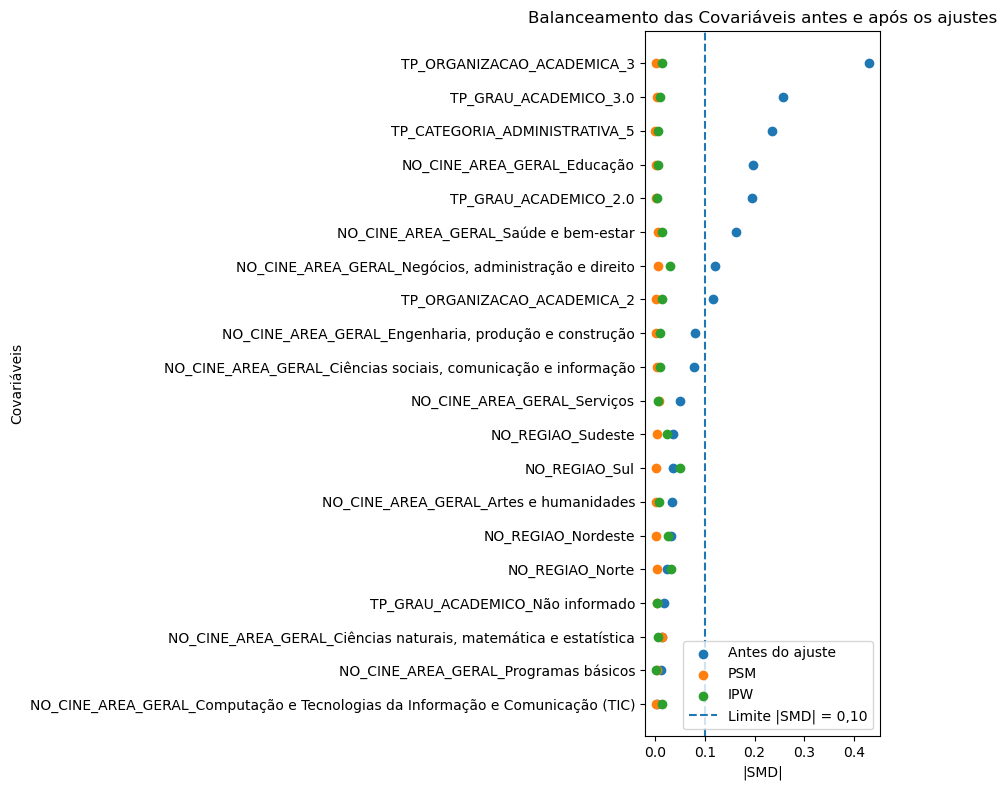

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 8))

plt.scatter(
    comparacao_balanceamento["Antes"],
    comparacao_balanceamento["Variavel"],
    label="Antes do ajuste"
)

plt.scatter(
    comparacao_balanceamento["PSM"],
    comparacao_balanceamento["Variavel"],
    label="PSM"
)

plt.scatter(
    comparacao_balanceamento["IPW"],
    comparacao_balanceamento["Variavel"],
    label="IPW"
)

plt.axvline(
    x=0.10,
    linestyle="--",
    label="Limite |SMD| = 0,10"
)

plt.xlabel("|SMD|")
plt.ylabel("Covariáveis")
plt.title("Balanceamento das Covariáveis antes e após os ajustes")

plt.legend()
plt.tight_layout()
plt.show()

## 11. Estimativa do efeito

Após a aplicação dos métodos de ajuste e a verificação do balanceamento das covariáveis, os efeitos estimados são organizados de forma conjunta.

São apresentadas a diferença bruta entre tratados e controles, observada antes de qualquer ajuste, e as estimativas do efeito médio do tratamento sobre os tratados (ATT) obtidas pelo Propensity Score Matching e pelo IPW.

Essa comparação permite avaliar em que medida o ajuste das características observáveis modifica a diferença inicialmente observada entre os grupos.

In [30]:
resultados_efeito = pd.DataFrame({
    "Estimativa": [
        "Diferença bruta",
        "PSM - ATT",
        "IPW - ATT"
    ],
    "Efeito": [
        diferenca_bruta,
        att_psm,
        att_ipw
    ]
})

resultados_efeito["Efeito_p.p."] = (
    resultados_efeito["Efeito"] * 100
)

display(resultados_efeito.round(4))

,Estimativa,Efeito,Efeito_p.p.
0,Diferença bruta,-0.0602,-6.0236
1,PSM - ATT,-0.0456,-4.5558
2,IPW - ATT,-0.0383,-3.8300


## 12. Comparação dos métodos

Após a aplicação do Propensity Score Matching e do IPW, os resultados são comparados de forma conjunta.

Embora os dois métodos utilizem o propensity score, eles ajustam os grupos de maneiras diferentes. O PSM seleciona controles com características semelhantes às dos tratados, enquanto o IPW atribui pesos às observações para construir uma população ponderada mais comparável.

A comparação considera principalmente dois aspectos:

- a qualidade do balanceamento alcançado após o ajuste;
- a magnitude do efeito médio do tratamento sobre os tratados (ATT).

A convergência entre os resultados obtidos por métodos distintos pode aumentar a confiança na robustez das conclusões, embora não elimine as limitações inerentes ao uso de dados observacionais.

In [31]:
comparacao_metodos = pd.DataFrame({
    "Metodo": [
        "PSM",
        "IPW"
    ],
    "Maior_Abs_SMD_Apos": [
        balanceamento_psm["Abs_SMD_Depois"].max(),
        balanceamento_ipw["Abs_SMD_Depois"].max()
    ],
    "ATT": [
        att_psm,
        att_ipw
    ]
})

comparacao_metodos["ATT_p.p."] = (
    comparacao_metodos["ATT"] * 100
)

display(comparacao_metodos.round(4))

,Metodo,Maior_Abs_SMD_Apos,ATT,ATT_p.p.
0,PSM,0.0128,-0.0456,-4.5558
1,IPW,0.0494,-0.0383,-3.8300


## 13. Conclusões

Este trabalho buscou responder à seguinte pergunta causal:

**Qual é o efeito da presença de estudantes beneficiários do Prouni sobre a conclusão nos cursos presenciais de instituições privadas de ensino superior no Brasil em 2023?**

A análise foi realizada com dados do Censo da Educação Superior de 2023, adotando o curso como unidade de análise. Foram comparados cursos privados presenciais com e sem presença de estudantes beneficiários do Prouni.

A comparação inicial, realizada antes de qualquer ajuste, mostrou que os cursos com presença de beneficiários apresentavam indicador médio de conclusão aproximadamente 6,02 pontos percentuais inferior ao observado nos cursos sem beneficiários. Entretanto, os grupos também apresentavam diferenças importantes em características institucionais, acadêmicas e geográficas, de modo que essa diferença bruta não poderia ser interpretada diretamente como efeito causal do programa.

Para aumentar a comparabilidade entre tratados e controles, foram aplicados dois métodos de inferência causal: Propensity Score Matching (PSM) e Inverse Probability Weighting (IPW). Em ambos os casos, o propensity score foi estimado a partir de características relacionadas à região, organização acadêmica, categoria administrativa, grau acadêmico e área de formação dos cursos.

Os diagnósticos de balanceamento indicaram melhora substancial após os dois métodos. O maior valor absoluto do SMD foi reduzido de aproximadamente 0,43 antes do ajuste para 0,013 após o PSM e 0,049 após o IPW. Em ambos os métodos, todas as covariáveis permaneceram abaixo do limite de |SMD| = 0,10 após o ajuste.

Após o pareamento, o PSM estimou um efeito médio do tratamento sobre os tratados (ATT) de aproximadamente **-4,56 pontos percentuais**. Pelo IPW, o ATT estimado foi de aproximadamente **-3,83 pontos percentuais**.

Os dois métodos, apesar de utilizarem estratégias distintas de ajuste, apresentaram resultados na mesma direção e com magnitudes relativamente próximas. Assim, considerando as características observáveis incluídas na análise, os resultados indicam que os cursos com presença de estudantes beneficiários do Prouni apresentaram, em 2023, indicador de conclusão entre aproximadamente **3,8 e 4,6 pontos percentuais inferior** ao observado em cursos comparáveis sem presença de beneficiários.

Esse resultado não deve ser interpretado como evidência de que o Prouni reduz individualmente a probabilidade de um estudante concluir o ensino superior. A unidade de análise deste estudo é o curso, e o tratamento corresponde à presença de beneficiários do programa no curso. Portanto, a interpretação dos resultados também deve permanecer no nível agregado dos cursos.

Além disso, por se tratar de uma análise observacional, a interpretação causal depende da hipótese de que as covariáveis utilizadas sejam suficientes para controlar os principais fatores de confusão observáveis. Características não observadas dos cursos, das instituições ou dos estudantes podem continuar influenciando simultaneamente a presença do Prouni e os resultados de conclusão.

Outra limitação decorre da utilização de dados referentes apenas ao ano de 2023. O indicador de conclusão utilizado corresponde à proporção de concluintes em relação aos matriculados no curso naquele ano e não representa o acompanhamento longitudinal de uma mesma coorte de estudantes desde o ingresso até a conclusão.

Dessa forma, os resultados devem ser compreendidos como uma estimativa do efeito da presença de beneficiários do Prouni sobre o indicador de conclusão dos cursos, condicionada às características observáveis e ao desenho adotado. Estudos futuros poderiam utilizar dados longitudinais, informações de anos anteriores ou dados individualizados dos estudantes para investigar com maior profundidade os mecanismos pelos quais o programa se relaciona à permanência e à conclusão no ensino superior.